In [1]:
#导入数据库+读数据
import pandas as pd

# 改成你的原始文件名
raw_path = "2022_LoL_esports_match_data_from_OraclesElixir.csv"

df = pd.read_csv(raw_path)

print(df.shape)
df.head()


C:\Users\32144\AppData\Local\Temp\ipykernel_14572\3424922830.py:6: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(raw_path)


(150588, 161)


,gameid,datacompleteness,url,league,year,split,playoffs,date,game,patch,...,opp_csat25,golddiffat25,xpdiffat25,csdiffat25,killsat25,assistsat25,deathsat25,opp_killsat25,opp_assistsat25,opp_deathsat25
0,ESPORTSTMNT01_2690210,complete,NaN,LCKC,2022,Spring,0,2022-01-10 07:44:08,1,12.01,...,203.0,605.0,-525.0,9.0,0.0,1.0,1.0,0.0,2.0,0.0
1,ESPORTSTMNT01_2690210,complete,NaN,LCKC,2022,Spring,0,2022-01-10 07:44:08,1,12.01,...,163.0,421.0,-903.0,-28.0,2.0,4.0,2.0,1.0,5.0,1.0
2,ESPORTSTMNT01_2690210,complete,NaN,LCKC,2022,Spring,0,2022-01-10 07:44:08,1,12.01,...,187.0,-149.0,-224.0,-5.0,1.0,3.0,0.0,3.0,4.0,3.0
3,ESPORTSTMNT01_2690210,complete,NaN,LCKC,2022,Spring,0,2022-01-10 07:44:08,1,12.01,...,284.0,-1288.0,-2005.0,-85.0,2.0,1.0,2.0,3.0,4.0,0.0
4,ESPORTSTMNT01_2690210,complete,NaN,LCKC,2022,Spring,0,2022-01-10 07:44:08,1,12.01,...,27.0,499.0,-314.0,12.0,1.0,3.0,2.0,0.0,7.0,2.0


In [2]:
df.columns.tolist()

['gameid',
 'datacompleteness',
 'url',
 'league',
 'year',
 'split',
 'playoffs',
 'date',
 'game',
 'patch',
 'participantid',
 'side',
 'position',
 'playername',
 'playerid',
 'teamname',
 'teamid',
 'champion',
 'ban1',
 'ban2',
 'ban3',
 'ban4',
 'ban5',
 'pick1',
 'pick2',
 'pick3',
 'pick4',
 'pick5',
 'gamelength',
 'result',
 'kills',
 'deaths',
 'assists',
 'teamkills',
 'teamdeaths',
 'doublekills',
 'triplekills',
 'quadrakills',
 'pentakills',
 'firstblood',
 'firstbloodkill',
 'firstbloodassist',
 'firstbloodvictim',
 'team kpm',
 'ckpm',
 'firstdragon',
 'dragons',
 'opp_dragons',
 'elementaldrakes',
 'opp_elementaldrakes',
 'infernals',
 'mountains',
 'clouds',
 'oceans',
 'chemtechs',
 'hextechs',
 'dragons (type unknown)',
 'elders',
 'opp_elders',
 'firstherald',
 'heralds',
 'opp_heralds',
 'void_grubs',
 'opp_void_grubs',
 'firstbaron',
 'barons',
 'opp_barons',
 'firsttower',
 'towers',
 'opp_towers',
 'firstmidtower',
 'firsttothreetowers',
 'turretplates',
 'op

In [5]:
#result 里面是什么值（等下要把它变成 win/lose）
df["result"].value_counts(dropna=False)

result
0    75294
1    75294
Name: count, dtype: int64

In [6]:
#保留我们需要的列

In [7]:
use_cols = [
    "gameid",
    "league",
    "year",
    "patch",
    "side",
    "teamname",
    "datacompleteness",
    "result",
    
    # 1. 前10分钟经济差
    "golddiffat10",
    
    # 2. 小龙
    "firstdragon",
    "dragons",
    "opp_dragons",
    
    # 3. 男爵
    "firstbaron",
    "barons",
    "opp_barons",
    
    # 4. 推塔
    "towers",
    "opp_towers",
    
    # 5. 视野
    "visionscore",
    "vspm",
    
    # 6. 可选：前10分钟击杀差
    "killsat10",
    "opp_killsat10"
]

# 如果有些列名不在，就先打印出来看一下
missing = [c for c in use_cols if c not in df.columns]
print("缺失的列：", missing)

# 只在列存在时才保留，保证不会直接报错
use_cols_existing = [c for c in use_cols if c in df.columns]

df_small = df[use_cols_existing].copy()

print(df_small.shape)
df_small.head()


缺失的列： []
(150588, 21)


,gameid,league,year,patch,side,teamname,datacompleteness,result,golddiffat10,firstdragon,...,opp_dragons,firstbaron,barons,opp_barons,towers,opp_towers,visionscore,vspm,killsat10,opp_killsat10
0,ESPORTSTMNT01_2690210,LCKC,2022,12.01,Blue,BRION Challengers,complete,0,52.0,NaN,...,NaN,NaN,0.0,0.0,NaN,NaN,26.0,0.9107,0.0,0.0
1,ESPORTSTMNT01_2690210,LCKC,2022,12.01,Blue,BRION Challengers,complete,0,485.0,NaN,...,NaN,NaN,0.0,0.0,NaN,NaN,48.0,1.6813,1.0,0.0
2,ESPORTSTMNT01_2690210,LCKC,2022,12.01,Blue,BRION Challengers,complete,0,162.0,NaN,...,NaN,NaN,0.0,0.0,NaN,NaN,29.0,1.0158,0.0,0.0
3,ESPORTSTMNT01_2690210,LCKC,2022,12.01,Blue,BRION Challengers,complete,0,296.0,NaN,...,NaN,NaN,0.0,0.0,NaN,NaN,25.0,0.8757,1.0,0.0
4,ESPORTSTMNT01_2690210,LCKC,2022,12.01,Blue,BRION Challengers,complete,0,528.0,NaN,...,NaN,NaN,0.0,0.0,NaN,NaN,69.0,2.4168,1.0,0.0


In [8]:
#过滤完整对局

In [9]:
# 只保留 datacompleteness 是 "complete" 的行（如果有这一列）
if "datacompleteness" in df_small.columns:
    print(df_small["datacompleteness"].value_counts(dropna=False))
    df_small = df_small[df_small["datacompleteness"] == "complete"]

# 去掉没有 result 的行
df_small = df_small.dropna(subset=["result"])

print(df_small.shape)
df_small.head()

datacompleteness
complete    127872
partial      22716
Name: count, dtype: int64
(127872, 21)


,gameid,league,year,patch,side,teamname,datacompleteness,result,golddiffat10,firstdragon,...,opp_dragons,firstbaron,barons,opp_barons,towers,opp_towers,visionscore,vspm,killsat10,opp_killsat10
0,ESPORTSTMNT01_2690210,LCKC,2022,12.01,Blue,BRION Challengers,complete,0,52.0,NaN,...,NaN,NaN,0.0,0.0,NaN,NaN,26.0,0.9107,0.0,0.0
1,ESPORTSTMNT01_2690210,LCKC,2022,12.01,Blue,BRION Challengers,complete,0,485.0,NaN,...,NaN,NaN,0.0,0.0,NaN,NaN,48.0,1.6813,1.0,0.0
2,ESPORTSTMNT01_2690210,LCKC,2022,12.01,Blue,BRION Challengers,complete,0,162.0,NaN,...,NaN,NaN,0.0,0.0,NaN,NaN,29.0,1.0158,0.0,0.0
3,ESPORTSTMNT01_2690210,LCKC,2022,12.01,Blue,BRION Challengers,complete,0,296.0,NaN,...,NaN,NaN,0.0,0.0,NaN,NaN,25.0,0.8757,1.0,0.0
4,ESPORTSTMNT01_2690210,LCKC,2022,12.01,Blue,BRION Challengers,complete,0,528.0,NaN,...,NaN,NaN,0.0,0.0,NaN,NaN,69.0,2.4168,1.0,0.0


In [10]:
df_small["win"] = df_small["result"].astype(int)
df_small["win"].value_counts(dropna=False)


win
0    63936
1    63936
Name: count, dtype: int64

In [11]:
#从“选手级”合并到“队伍级”（每队每局一行）

#现在每一行是一名选手，我们要按 gameid + side 合并成“某队在某一局”

In [13]:
group_cols = ["gameid", "side"]

agg_dict = {
    "league": "first",
    "year": "first",
    "patch": "first",
    "teamname": "first",
    "datacompleteness": "first",
    "result": "first",
    "win": "first",
    
    # 前10分钟经济差
    "golddiffat10": "first",
    
    # 小龙
    "firstdragon": "first",
    "dragons": "first",
    "opp_dragons": "first",
    
    # 男爵
    "firstbaron": "first",
    "barons": "first",
    "opp_barons": "first",
    
    # 推塔
    "towers": "first",
    "opp_towers": "first",
    
    # 视野：队伍总和
    "visionscore": "sum",
    "vspm": "sum",
    
    # 可选：前10分钟击杀差
    "killsat10": "first",
    "opp_killsat10": "first",
}

team_df = df_small.groupby(group_cols).agg(agg_dict).reset_index()

print(team_df.shape)
team_df.head()
#现在 team_df 的每一行就是：

#某一局 + 某一边（blue/red） 的队伍整体数据


(21312, 22)


,gameid,side,league,year,patch,teamname,datacompleteness,result,win,golddiffat10,...,opp_dragons,firstbaron,barons,opp_barons,towers,opp_towers,visionscore,vspm,killsat10,opp_killsat10
0,ESPORTSTMNT01_2690210,Blue,LCKC,2022,12.01,BRION Challengers,complete,0,0,52.0,...,3.0,0.0,0.0,0.0,3.0,6.0,394.0,13.8005,0.0,0.0
1,ESPORTSTMNT01_2690210,Red,LCKC,2022,12.01,Nongshim Esports Academy,complete,1,1,-52.0,...,1.0,0.0,0.0,0.0,6.0,3.0,410.0,14.3609,0.0,0.0
2,ESPORTSTMNT01_2690219,Blue,LCKC,2022,12.01,T1 Esports Academy,complete,0,0,-894.0,...,4.0,0.0,0.0,0.0,3.0,11.0,554.0,15.7238,0.0,1.0
3,ESPORTSTMNT01_2690219,Red,LCKC,2022,12.01,Liiv SANDBOX Youth,complete,1,1,894.0,...,1.0,1.0,0.0,0.0,11.0,3.0,692.0,19.6404,1.0,0.0
4,ESPORTSTMNT01_2690227,Blue,LCKC,2022,12.01,KT Rolster Challengers,complete,1,1,53.0,...,1.0,1.0,0.0,0.0,11.0,2.0,528.0,16.0650,0.0,0.0


In [16]:
#假如几个衍生字段
#目的是为了更方便做图：加入tower_diff：推塔差 team_vspm：全队视野强度  kills_diff_10：前 10 分钟击杀差

In [18]:
# 推塔差
team_df["tower_diff"] = team_df["towers"] - team_df["opp_towers"]

# 视野强度：直接用队伍总 vspm
team_df["team_vspm"] = team_df["vspm"]

# 前10分钟击杀差
if "killsat10" in team_df.columns and "opp_killsat10" in team_df.columns:
    team_df["kills_diff_10"] = team_df["killsat10"] - team_df["opp_killsat10"]

team_df.head()


,gameid,side,league,year,patch,teamname,datacompleteness,result,win,golddiffat10,...,opp_barons,towers,opp_towers,visionscore,vspm,killsat10,opp_killsat10,tower_diff,team_vspm,kills_diff_10
0,ESPORTSTMNT01_2690210,Blue,LCKC,2022,12.01,BRION Challengers,complete,0,0,52.0,...,0.0,3.0,6.0,394.0,13.8005,0.0,0.0,-3.0,13.8005,0.0
1,ESPORTSTMNT01_2690210,Red,LCKC,2022,12.01,Nongshim Esports Academy,complete,1,1,-52.0,...,0.0,6.0,3.0,410.0,14.3609,0.0,0.0,3.0,14.3609,0.0
2,ESPORTSTMNT01_2690219,Blue,LCKC,2022,12.01,T1 Esports Academy,complete,0,0,-894.0,...,0.0,3.0,11.0,554.0,15.7238,0.0,1.0,-8.0,15.7238,-1.0
3,ESPORTSTMNT01_2690219,Red,LCKC,2022,12.01,Liiv SANDBOX Youth,complete,1,1,894.0,...,0.0,11.0,3.0,692.0,19.6404,1.0,0.0,8.0,19.6404,1.0
4,ESPORTSTMNT01_2690227,Blue,LCKC,2022,12.01,KT Rolster Challengers,complete,1,1,53.0,...,0.0,11.0,2.0,528.0,16.0650,0.0,0.0,9.0,16.0650,0.0


In [19]:
clean_path = "lol_team_clean.csv"
team_df.to_csv(clean_path, index=False)
clean_path

'lol_team_clean.csv'

In [20]:
#做前 10 分钟经济差 vs 赢率的图

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

# 读入刚刚清洗好的表
df = pd.read_csv("lol_team_clean.csv")

df.shape, df.columns

((21312, 25),
 Index(['gameid', 'side', 'league', 'year', 'patch', 'teamname',
        'datacompleteness', 'result', 'win', 'golddiffat10', 'firstdragon',
        'dragons', 'opp_dragons', 'firstbaron', 'barons', 'opp_barons',
        'towers', 'opp_towers', 'visionscore', 'vspm', 'killsat10',
        'opp_killsat10', 'tower_diff', 'team_vspm', 'kills_diff_10'],
       dtype='object'))

In [22]:
#简单看一下经济差的分布（决定分箱）

In [23]:
df["golddiffat10"].describe()


count    21312.000000
mean         0.304336
std        586.108196
min      -3184.000000
25%       -343.000000
50%          0.000000
75%        343.000000
max       3184.000000
Name: golddiffat10, dtype: float64

In [24]:
#把前 10 分钟经济差分箱 + 计算每个区间的胜率

In [25]:
# 1. 去掉没有 golddiffat10 或 win 的行
sub = df.dropna(subset=["golddiffat10", "win"]).copy()

# 2. 定义金钱差分箱（单位：金币）
bins = [-10000, -3000, -2000, -1000, 0, 1000, 2000, 3000, 10000]
labels = [
    "< -3000",
    "-3000 ~ -2000",
    "-2000 ~ -1000",
    "-1000 ~ 0",
    "0 ~ 1000",
    "1000 ~ 2000",
    "2000 ~ 3000",
    "> 3000"
]

sub["gold_bin"] = pd.cut(sub["golddiffat10"], bins=bins, labels=labels)

# 3. 按金钱差区间计算：
#    mean(win) = 胜率
#    count = 样本数（方便标在图上）
gold_win = (
    sub.dropna(subset=["gold_bin"])
       .groupby("gold_bin", observed=False)["win"]
       .agg(["mean", "count"])
       .reset_index()
)

gold_win


,gold_bin,mean,count
0,< -3000,0.000000,2
1,-3000 ~ -2000,0.169492,59
2,-2000 ~ -1000,0.277463,883
3,-1000 ~ 0,0.426206,9723
4,0 ~ 1000,0.573828,9705
5,1000 ~ 2000,0.724886,876
6,2000 ~ 3000,0.822581,62
7,> 3000,1.000000,2


In [26]:
#画一张“前 10 分钟经济差 vs 胜率”的柱状图

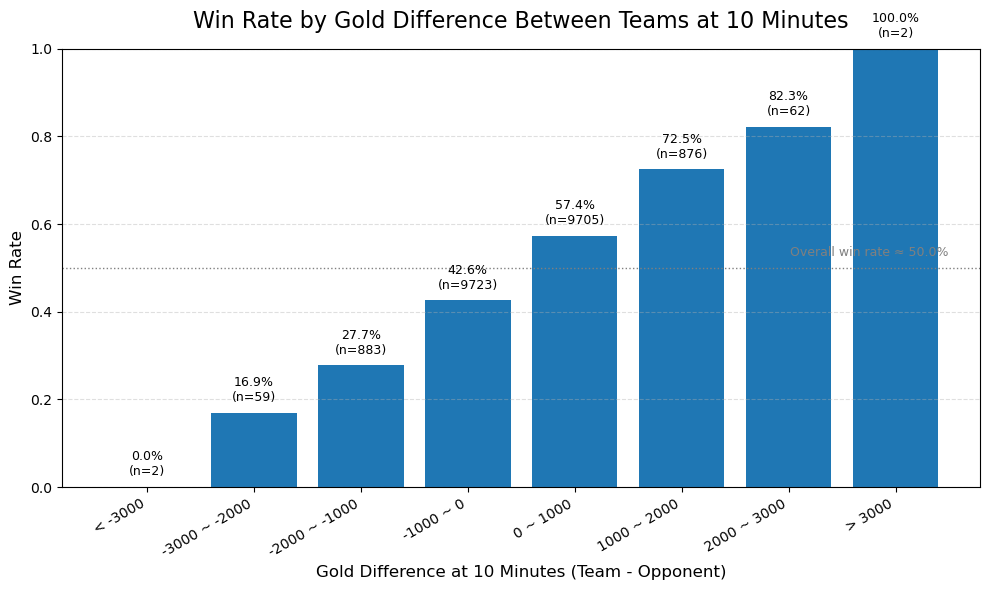

In [30]:
plt.figure(figsize=(10, 6))

# x 轴：经济差区间；y 轴：胜率
x = gold_win["gold_bin"].astype(str)
y = gold_win["mean"]

bars = plt.bar(x, y)

# y 轴从 0 到 1（0% ~ 100%）
plt.ylim(0, 1)

# 标题 & 轴标签
plt.title("Win Rate by Gold Difference Between Teams at 10 Minutes", fontsize=16, pad=15)
plt.xlabel("Gold Difference at 10 Minutes (Team - Opponent)", fontsize=12)
plt.ylabel("Win Rate", fontsize=12)

# x 轴标签倾斜一点好看
plt.xticks(rotation=30, ha="right")

# 加一点网格，让读数更清晰
plt.grid(axis="y", linestyle="--", alpha=0.4)

# 在每个柱子上标注胜率（%）和样本数（N）
for bar, win_rate, count in zip(bars, y, gold_win["count"]):
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.02,
        f"{win_rate*100:.1f}%\n(n={count})",
        ha="center",
        va="bottom",
        fontsize=9
    )

# 画一条“全局平均胜率”的参考线（理论上约 50%）
overall_win_rate = sub["win"].mean()
plt.axhline(overall_win_rate, color="grey", linestyle=":", linewidth=1)
plt.text(
    len(x) - 0.5,
    overall_win_rate + 0.02,
    f"Overall win rate ≈ {overall_win_rate*100:.1f}%",
    ha="right",
    va="bottom",
    fontsize=9,
    color="grey"
)

plt.tight_layout()
plt.savefig("gold_diff_winrate.png", dpi=300, bbox_inches="tight")
plt.show()
